## State Estimation (With data from publicly available dataset Leg-KILO)

https://github.com/ouguangjun/legkilo-dataset

Not existing:
- contact_forces (maybe in joint_foot last 4 of effort)
- contact_state (can be estimated as contact_state = force > threshold)

Interesting topics:
- **/high_state** (contains position and velocity estimation of unitree)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.kf_utils import *
from utils.legkilo_reader import *
from utils.plot_data import *
from utils.run_estimation import run_state_estimation

#### Read ROS and Ground truth file

In [3]:
legkilo_reader = LegKILOReader(rosbag_path="../custom_datasets/corridor.bag",
                               gt_path="../custom_datasets/corridor_tum.txt",
                               output_dir="../results/leg-kilo",
                               file_name="legkilo-data_corridor")

# legkilo_reader.inspect_rosbag_file()

Reading ground truth from ../custom_datasets/corridor_tum.txt
Loading data from ../results/leg-kilo/legkilo-data_corridor.npz


#### State Estimation

In [4]:
start = 0
end = 100000
leg_kilo_data = legkilo_reader.legkilo_data

mean_dt = np.round(np.mean(leg_kilo_data["dt"][start:end]), 4)
leg_kilo_data = legkilo_reader.legkilo_data
results_leg_kilo_est = run_state_estimation(dt=mean_dt,
                                            base_orient=leg_kilo_data['base_orient_quat'][start:end],
                                            base_ang_vel=leg_kilo_data['base_ang_vel'][start:end],
                                            joint_pos=leg_kilo_data['joint_pos'][start:end],
                                            joint_vel=leg_kilo_data['joint_vel'][start:end],
                                            joint_acc=leg_kilo_data["joint_acc"][start:end],
                                            joint_torque=leg_kilo_data['joint_torque'][start:end], # use torque and contact state to estimate contact force
                                            contact_forces=leg_kilo_data['foot_force'][start:end], # use singular force value to estimate contact state
                                            Q=0.002,
                                            R=0.001,
                                            L1=100,
                                            L2=10000,
                                            contact_state_threshold=200,
                                            model_name="go1",
                                            est_mode=4)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Running state estimation:   0%|          | 108/100000 [00:00<03:04, 541.21it/s]

Estimating contact state based on threshold
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 100000/100000 [02:44<00:00, 609.58it/s]


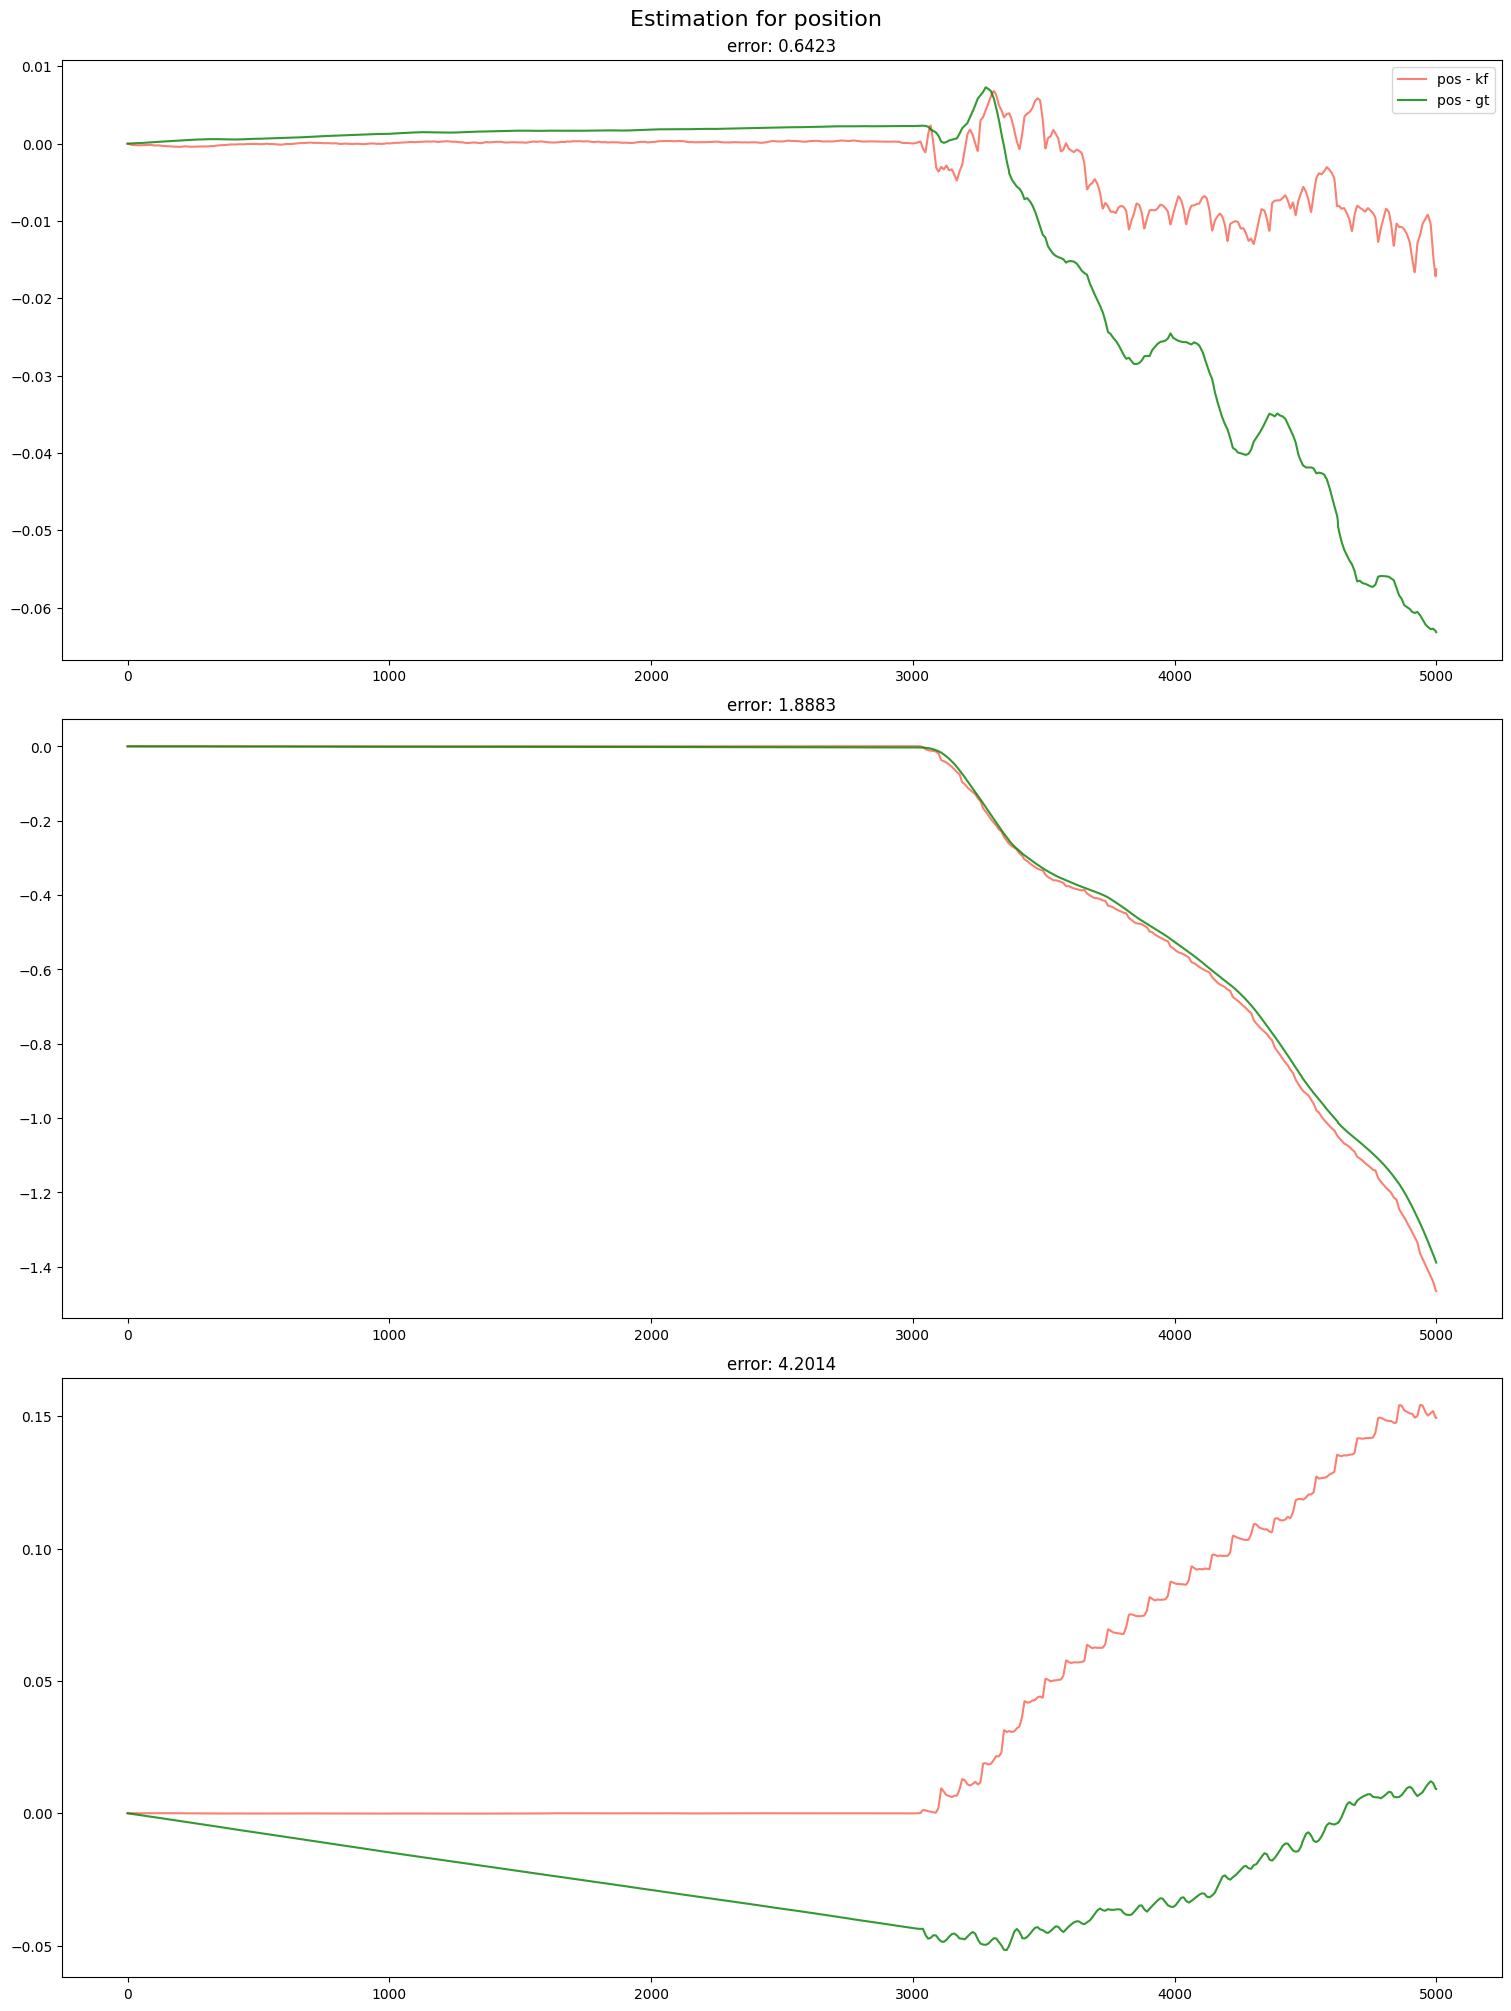

In [13]:
estimation_plot(gt_value=leg_kilo_data["base_pos_o"][start:end],
                est_value=results_leg_kilo_est["pos_update"],
                label="pos",
                start=0,
                end=5000,
                title="Estimation for position")

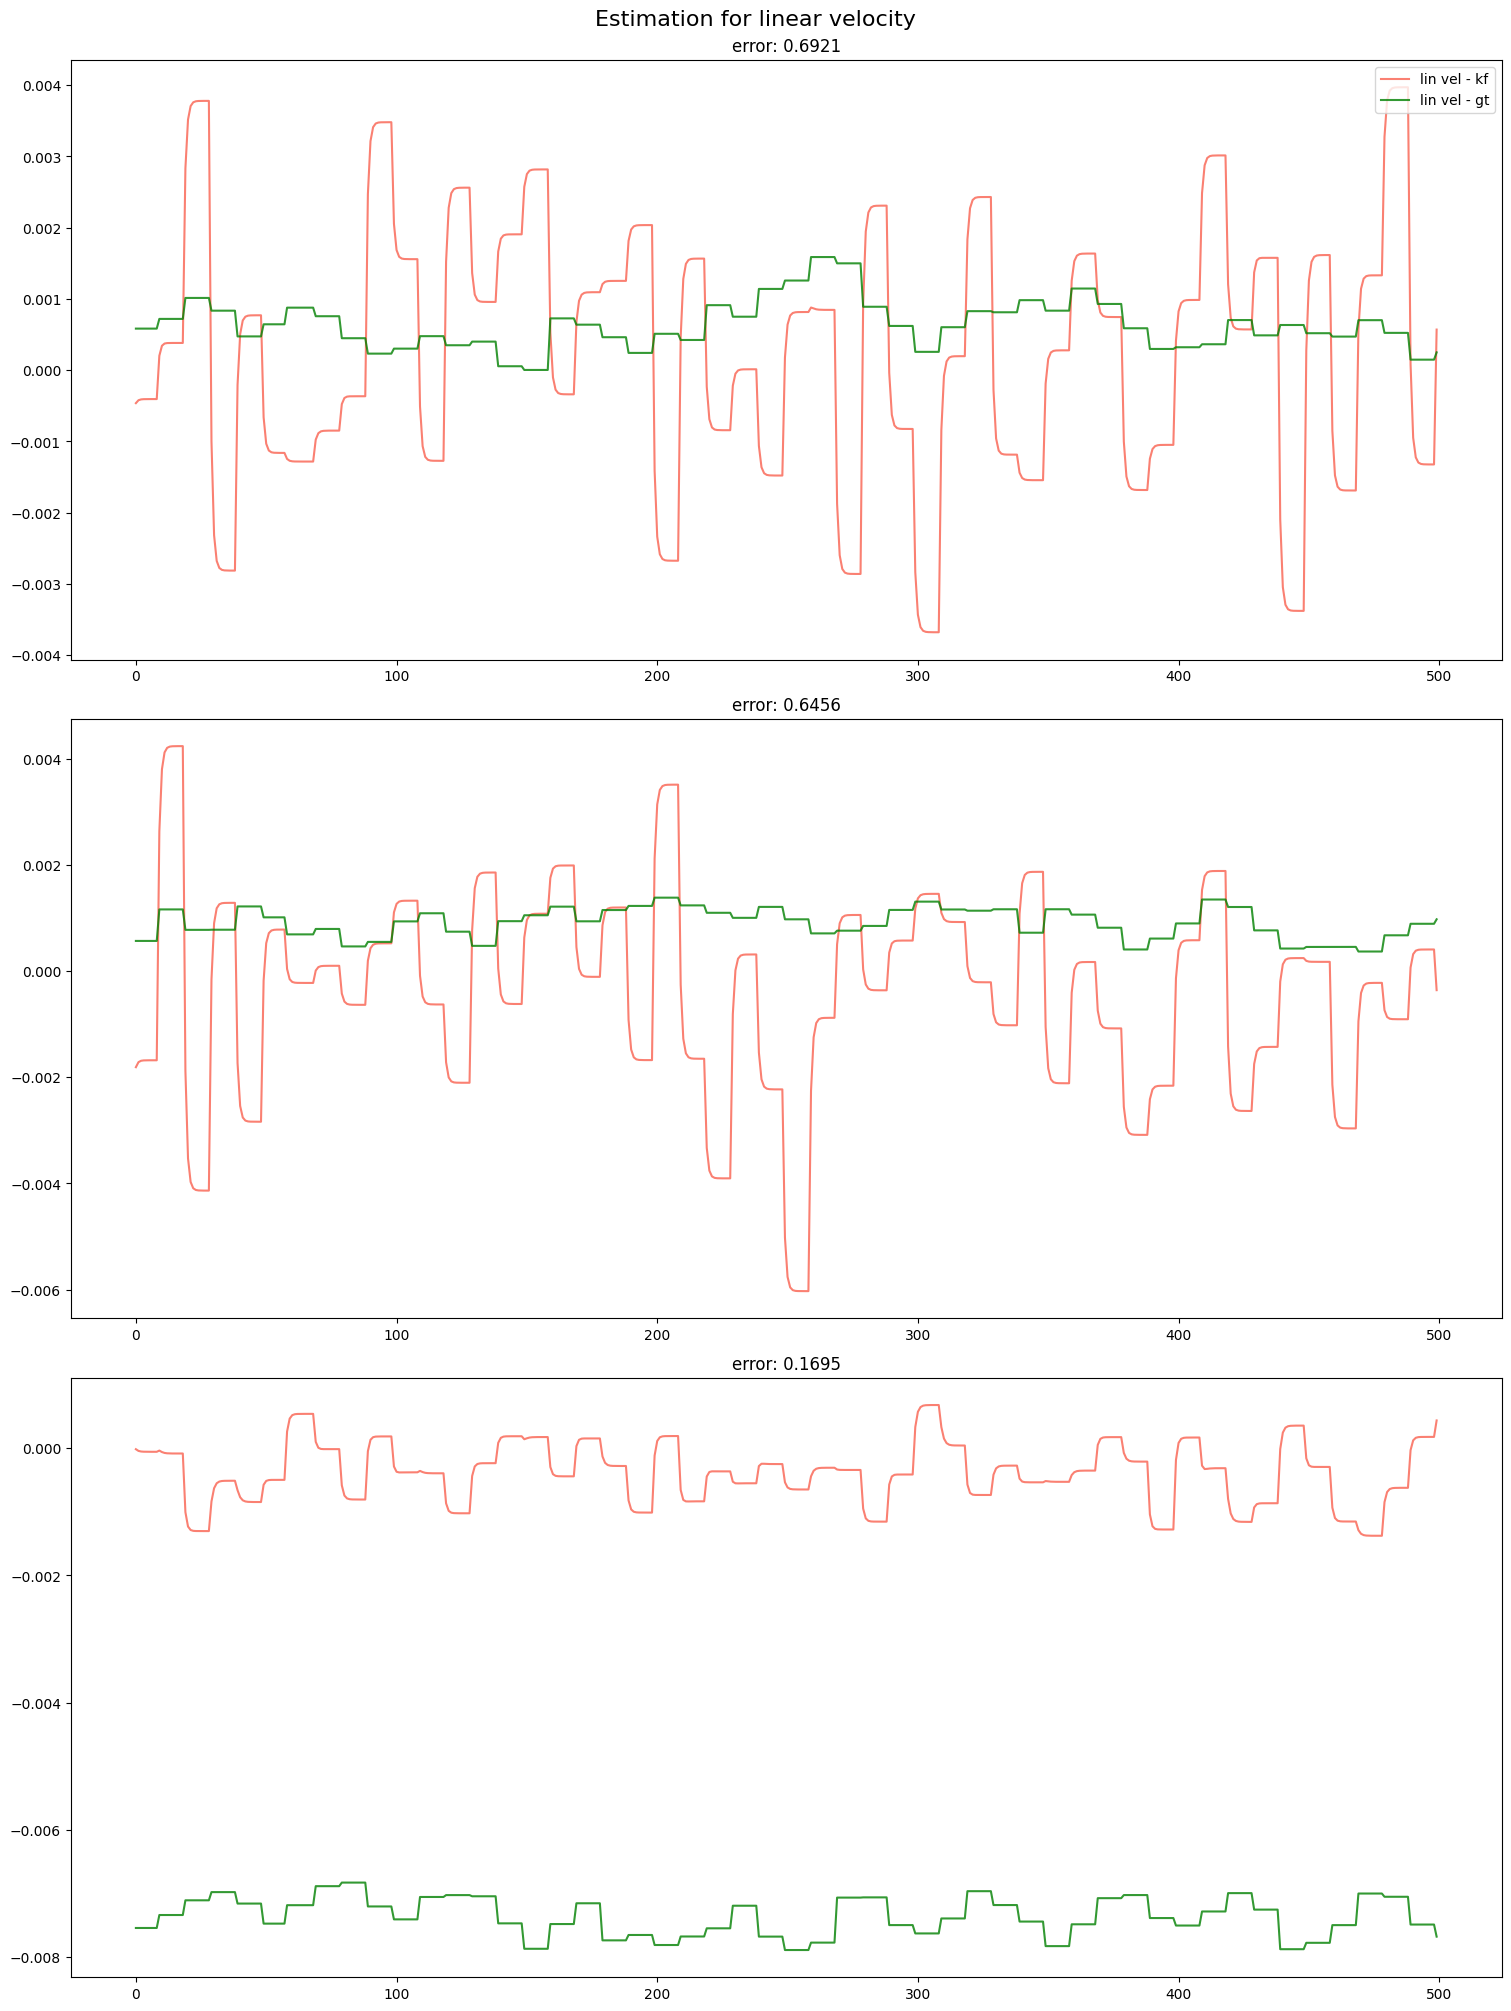

In [16]:
estimation_plot(gt_value=leg_kilo_data["base_vel_w"][start:end],
                est_value=results_leg_kilo_est["vel_update"],
                label="lin vel",
                start=500,
                end=1000,
                title="Estimation for linear velocity")

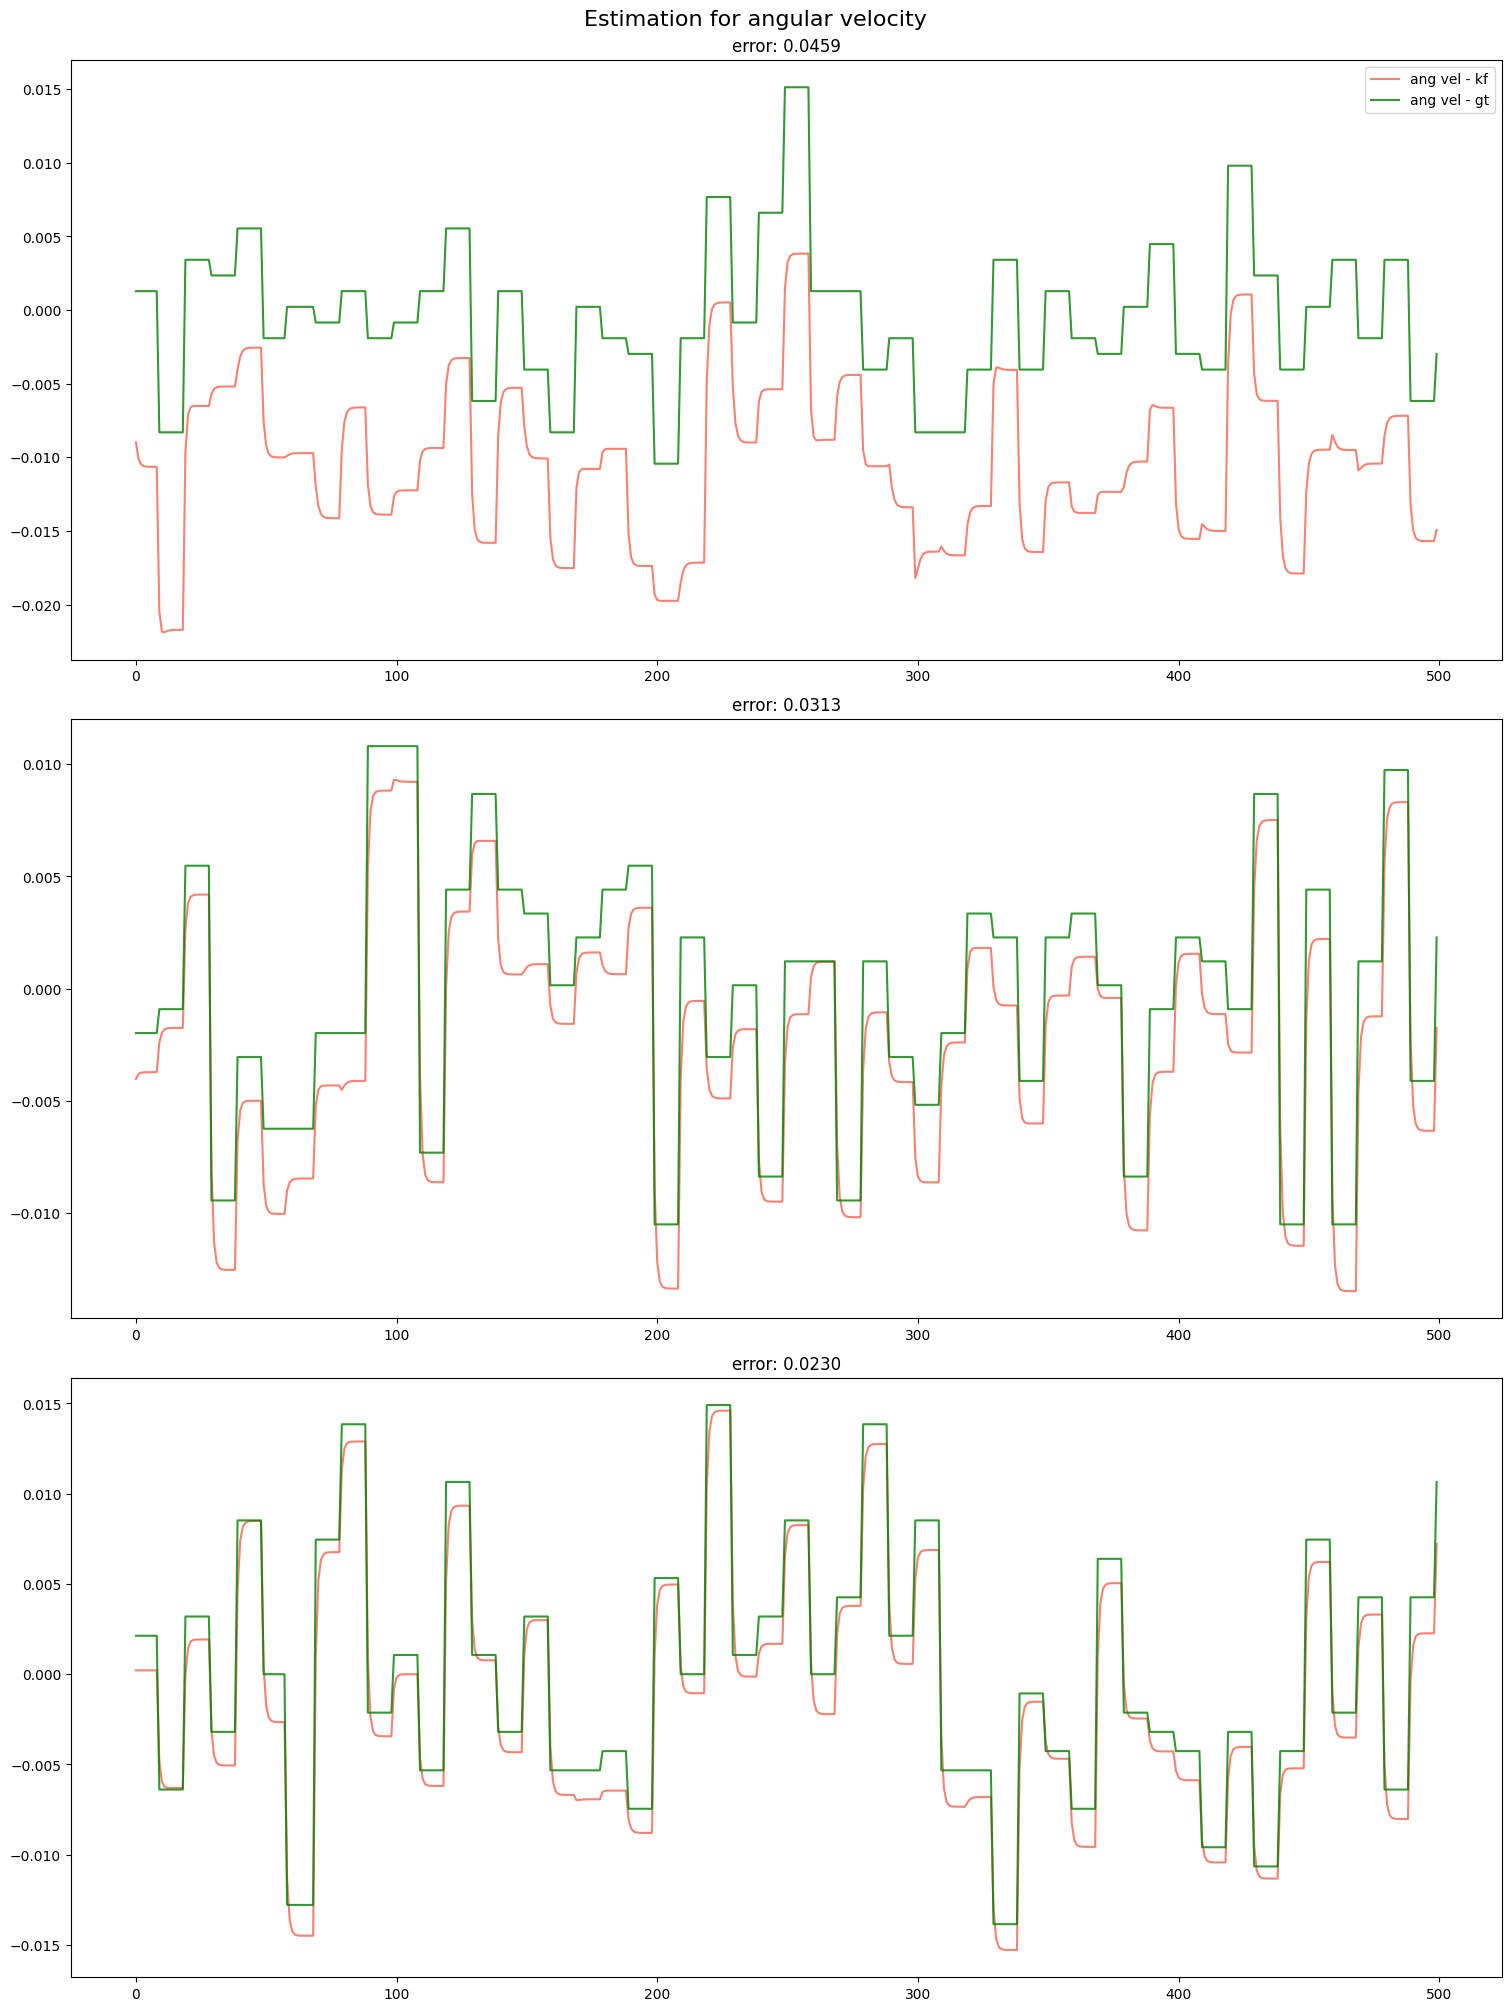

In [17]:
estimation_plot(gt_value=leg_kilo_data["base_ang_vel"][start:end],
                est_value=results_leg_kilo_est["ang_vel_update"],
                label="ang vel",
                start=500,
                end=1000,
                title="Estimation for angular velocity")

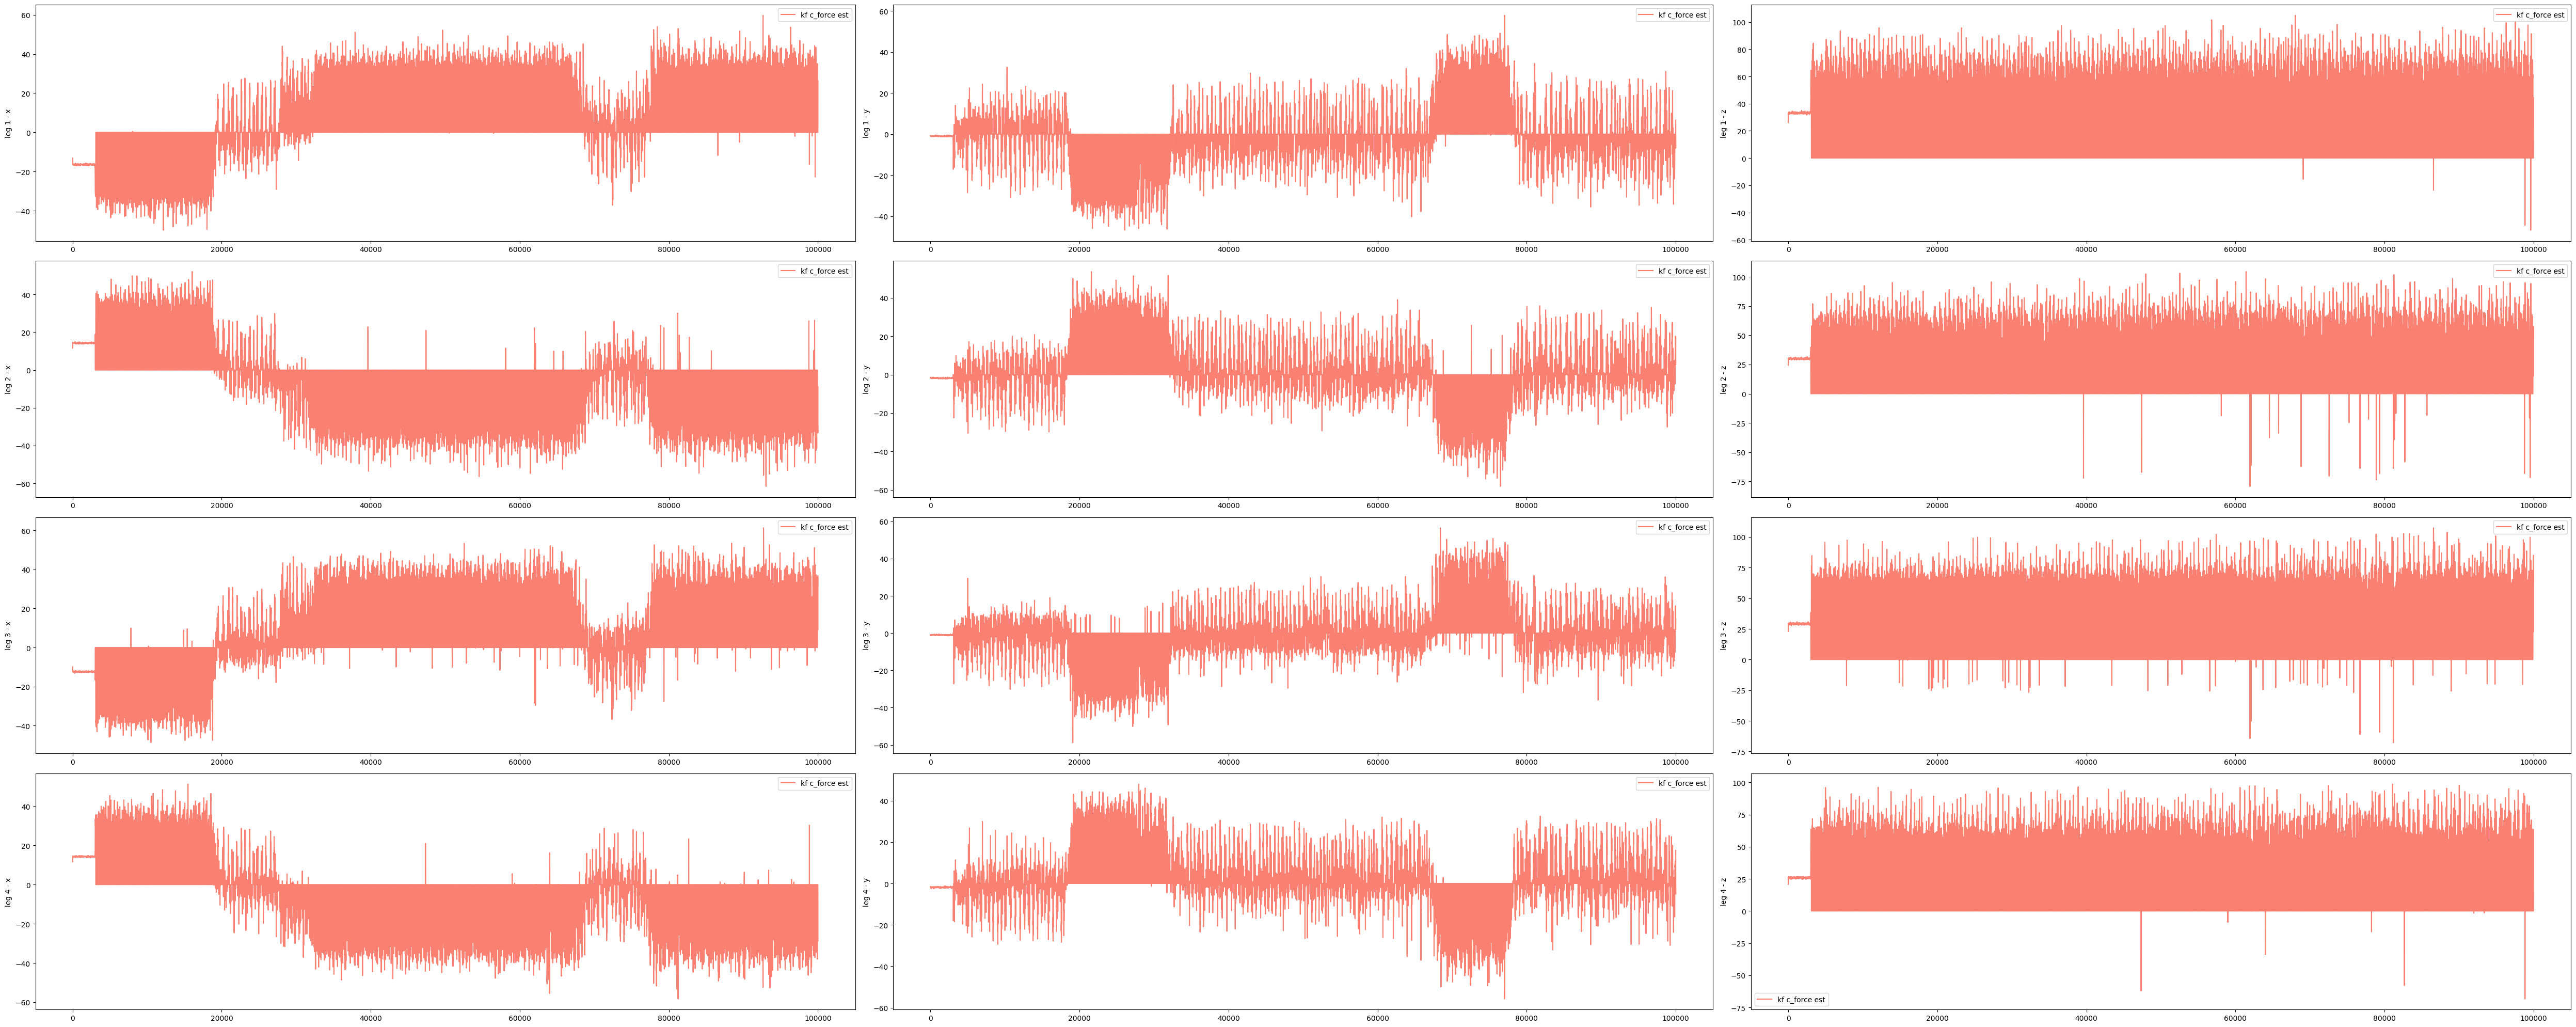

In [19]:
fig, axes = plt.subplots(4, 3, figsize=(50,20))

c_force_est = results_leg_kilo_est["c_force_update"]
start = 0
end = 100000

leg_labels = np.arange(start=1, stop=5)
force_labels = ['x', 'y', 'z']
for i in range(4):
    for j in range(3):
        axes[i, j].plot(np.arange(end-start), c_force_est[start:end, i, j], label="kf c_force est", color="salmon")
        axes[i, j].set_ylabel(f'leg {leg_labels[i]} - {force_labels[j]}')
        axes[i, j].legend()

plt.tight_layout()
plt.show()